Starting reliability_plots function call...

>>> Processing training center: UtAmSi
  --> Processing loss: CE (run: training_Utrecht_Amsterdam_Singapore_CE_3684_best)
    --> Processing test center: UMCL
      Found 30 subjects for UMCL.
        Processing subject 1/30: 20 (from /home/appuser/Code/datasets/wmh/training/UMCL/20)
        Processing subject 2/30: 15 (from /home/appuser/Code/datasets/wmh/training/UMCL/15)
        Processing subject 2/30: 15 (from /home/appuser/Code/datasets/wmh/training/UMCL/15)
        Processing subject 3/30: 11 (from /home/appuser/Code/datasets/wmh/training/UMCL/11)
        Processing subject 3/30: 11 (from /home/appuser/Code/datasets/wmh/training/UMCL/11)
        Processing subject 4/30: 27 (from /home/appuser/Code/datasets/wmh/training/UMCL/27)
        Processing subject 4/30: 27 (from /home/appuser/Code/datasets/wmh/training/UMCL/27)
        Processing subject 5/30: 23 (from /home/appuser/Code/datasets/wmh/training/UMCL/23)
        Processing subject

/tmp/ipykernel_422/1758091484.py:322: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color = loss_colors.get(loss_name_plot, plt.cm.get_cmap('tab10')(loss_idx % 10)) # type: ignore


    Saving figure to: notebooks/main/figs/pdfs/Figure7.pdf


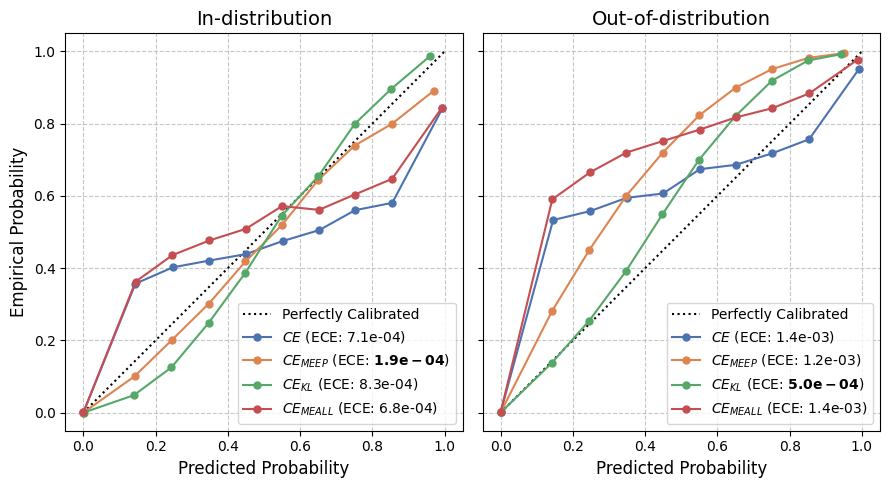

>>> Reliability plots processing complete.
Reliability_plots function call finished.


In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib # Ensure nibabel is imported
from sklearn.calibration import calibration_curve # Explicit import

sys.path.append(os.path.expanduser('~/Code/wmh-mc-seg'))  # For VSCode

from src.datamodules import WMHDataModule
from notebooks.utils.metrics_utils import * # Imports plt, sns, pd, np, and hopefully get_gt_paths, get_ece
from scipy.stats import pearsonr, spearmanr

# Font sizes
SMALL_SIZE = 10
MEDIUM_SIZE = 12
BIGGER_SIZE = 14

# Apply global font settings
plt.rc('font', size=SMALL_SIZE, family='sans-serif')
plt.rc('axes', titlesize=MEDIUM_SIZE)
plt.rc('xtick', labelsize=SMALL_SIZE)
plt.rc('ytick', labelsize=SMALL_SIZE)
plt.rc('legend', fontsize=SMALL_SIZE)
plt.rc('figure', titlesize=BIGGER_SIZE)
plt.rcParams['text.usetex'] = False # Ensure mathtext is used


data_root = os.path.expanduser('~/Code/datasets/wmh/')
centers_train = ['UtAmSi']
# Initial list of test centers, will be modified
current_centers_test = ['Utrecht', 'Amsterdam', 'Singapore', 'UMCL']
group_test = {'UtAmSi': ['Utrecht', 'Amsterdam', 'Singapore']}
rename_centers = {'UtAmSi': 'In-distribution', 'UMCL': 'Out-of-distribution'}

losses = ['CE', 'CE_MEEP', 'CE_KL', 'CE_MEALL']
runs_to_compare = {
    'CE UtAmSi': 'training_Utrecht_Amsterdam_Singapore_CE_3684_best',
    'CE_MEALL UtAmSi': 'training_Utrecht_Amsterdam_Singapore_MEALL_8766_best',
    'CE_MEEP UtAmSi': 'training_Utrecht_Amsterdam_Singapore_MEEP_6996_best',
    'CE_KL UtAmSi': 'training_Utrecht_Amsterdam_Singapore_cekl_4187_best',
}

test_splits = {}
for center_name_loop in ['Utrecht', 'Amsterdam', 'Singapore']: # Renamed center to avoid conflict
    dm = WMHDataModule(data_root, 1, f'training:{center_name_loop}', [.7, .1, .2],
                       seed=42)
    _, _, ts_spl = dm.generate_splits()
    test_splits[center_name_loop] = ts_spl

test_splits['UMCL'] = WMHDataModule(
    data_root, 1, 'training:UMCL', [0, 0, 1]).generate_splits()[2]

# Process grouped test centers carefully
processed_for_grouping = set()
final_centers_test = list(current_centers_test) # Work on a copy

for key, val_list in group_test.items():
    if key not in test_splits: # Initialize key for grouped data if it doesn't exist
        test_splits[key] = []
    for center_in_group in val_list:
        if center_in_group in test_splits:
            test_splits[key].extend(test_splits[center_in_group]) # Aggregate data
            # Consider if removing original test_splits entry is desired or if it should be kept
            # For now, assume it's removed to avoid duplicate processing if key is also in centers_test_arg
            # del test_splits[center_in_group] 
        if center_in_group in final_centers_test:
            final_centers_test.remove(center_in_group) # Remove from list of centers
        processed_for_grouping.add(center_in_group)
    if key not in final_centers_test: # Add the new group key
        final_centers_test.append(key)
    
plot_data = {
    'centers_train': centers_train,
    'runs_to_compare': runs_to_compare,
    'centers_test': final_centers_test, # Use the correctly processed list
    'test_splits': test_splits,
    'losses': losses,
}

loss_colors = {
    'CE': '#4C72B0', 'CE_MEEP': '#DD8452',
    'CE_KL': '#55A868', 'CE_MEALL': '#C44E52',
}

# Placeholder for get_gt_paths and get_ece if not in metrics_utils
# Ensure these are correctly defined in your environment
if 'get_gt_paths' not in globals():
    def get_gt_paths(split_data_arg):
        # print(f"WARNING: Using DUMMY get_gt_paths for: {split_data_arg}. This will likely fail to find real data.")
        return [] 
if 'get_ece' not in globals():
    def get_ece(y_pred_probs, y_true_labels): # <-- MODIFIED DUMMY to match assumed signature
        # print(f"WARNING: Using DUMMY get_ece (no n_bins). Returning NaN.")
        # A simple ECE-like calculation for dummy
        if len(y_pred_probs) != len(y_true_labels) or len(y_true_labels) == 0:
            return np.nan
        df = pd.DataFrame({'y_pred_probs': y_pred_probs, 'y_true_labels': y_true_labels})
        # Simplified binning for dummy
        bins = np.linspace(0, 1, 11) # 10 bins
        df['bin'] = pd.cut(df['y_pred_probs'], bins, include_lowest=True, right=True)
        
        bin_stats = df.groupby('bin', observed=False).agg(
            count=('y_pred_probs', 'count'),
            mean_pred_prob=('y_pred_probs', 'mean'),
            mean_true_prob=('y_true_labels', 'mean')
        ).dropna() # Drop bins with no samples

        if bin_stats.empty:
            return np.nan
            
        ece = np.sum(np.abs(bin_stats['mean_pred_prob'] - bin_stats['mean_true_prob']) * (bin_stats['count'] / len(df)))
        return ece


def reliability_plots(plot_data_config, rename_centers_config, max_voxels_for_calibration=30_000_000):
    num_bins = 10 # This is used by calibration_curve
    centers_train_arg, runs_to_compare_arg, centers_test_arg_orig, test_splits_arg, losses_arg = plot_data_config.values()

    for tr_center in centers_train_arg:
        processed_plot_data = {}
        print(f"\n>>> Processing training center: {tr_center}")

        for loss in losses_arg:
            processed_plot_data[loss] = {}
            run_name_key = f'{loss} {tr_center}'
            if run_name_key not in runs_to_compare_arg:
                print(f"  [INFO] Skipping loss {loss}: No run found for key {run_name_key}.")
                continue
            run_name = runs_to_compare_arg[run_name_key]
            print(f"  --> Processing loss: {loss} (run: {run_name})")

            for ts_center in centers_test_arg_orig: # Use original order for data processing
                print(f"    --> Processing test center: {ts_center}")
                if ts_center not in test_splits_arg:
                    print(f"      [INFO] Skipping test center {ts_center}: Not found in test_splits_arg.")
                    processed_plot_data[loss][ts_center] = {'emp_probs': np.array([]), 'pred_probs': np.array([]), 'ece': np.nan}
                    continue
                
                gt_pths = get_gt_paths(test_splits_arg[ts_center])
                if not gt_pths:
                    print(f"      [INFO] No GT paths found for {ts_center} using loss {loss}. Skipping.")
                    processed_plot_data[loss][ts_center] = {'emp_probs': np.array([]), 'pred_probs': np.array([]), 'ece': np.nan}
                    continue

                current_preds_list_of_arrays = []
                current_gts_list_of_arrays = []
                print(f"      Found {len(gt_pths)} subjects for {ts_center}.")

                for subj_idx, subj_path in enumerate(gt_pths):
                    if not isinstance(subj_path, str) or subj_path is None:
                        print(f"        [WARNING] Invalid subject path received: {subj_path}. Skipping this entry.")
                        continue
                    print(f"        Processing subject {subj_idx + 1}/{len(gt_pths)}: {os.path.basename(subj_path)} (from {subj_path})")
                    try:
                        gt_path_full = os.path.join(subj_path, f'gt_wmh_{run_name}.nii.gz')
                        pred_softmax_path_full = os.path.join(subj_path, f'pred_wmh_softmax_{run_name}.nii.gz')

                        if not os.path.exists(gt_path_full):
                            print(f"          [WARNING] GT file missing: {gt_path_full}")
                            continue
                        if not os.path.exists(pred_softmax_path_full):
                            print(f"          [WARNING] Pred file missing: {pred_softmax_path_full}")
                            continue
                        
                        pred_softmax_img = nib.load(pred_softmax_path_full)
                        gt_img = nib.load(gt_path_full)
                        
                        pred_softmax_data = pred_softmax_img.get_fdata()
                        gt_data = gt_img.get_fdata().astype(bool)

                        # print(f"          Loaded pred_softmax_data: shape={pred_softmax_data.shape}, dtype={pred_softmax_data.dtype}")
                        # print(f"          Loaded gt_data: shape={gt_data.shape}, dtype={gt_data.dtype}")

                        if pred_softmax_data.shape[:gt_data.ndim] != gt_data.shape:
                             print(f"          [ERROR] Spatial dimension mismatch between pred {pred_softmax_data.shape} and gt {gt_data.shape}. Skipping subject.")
                             continue

                        if pred_softmax_data.ndim == gt_data.ndim + 1 and pred_softmax_data.shape[-1] >= 2:
                            pred_subject_probs = pred_softmax_data[..., 1]
                        elif pred_softmax_data.ndim == gt_data.ndim:
                            pred_subject_probs = pred_softmax_data
                        else:
                            print(f"          [ERROR] Unexpected pred_softmax shape {pred_softmax_data.shape} vs GT shape {gt_data.shape}. Skipping subject.")
                            continue
                        
                        if pred_subject_probs.shape != gt_data.shape:
                             print(f"          [ERROR] Shape mismatch after selecting positive class pred {pred_subject_probs.shape} and gt {gt_data.shape}. Skipping subject.")
                             continue

                        current_preds_list_of_arrays.append(pred_subject_probs.flatten())
                        current_gts_list_of_arrays.append(gt_data.flatten())
                        # print(f"          Appended {pred_subject_probs.size} voxels for subject {os.path.basename(subj_path)}.")

                    except FileNotFoundError as fnf_error:
                        print(f"        [ERROR] FileNotFoundError for subject {subj_path}: {fnf_error}")
                    except Exception as e:
                        print(f"        [CRITICAL ERROR] Processing subject {subj_path} failed: {e}")
                        import traceback
                        traceback.print_exc()
                        continue

                if not current_preds_list_of_arrays:
                    print(f"      [INFO] No data accumulated for {loss} on {ts_center} after subject loop.")
                    processed_plot_data[loss][ts_center] = {'emp_probs': np.array([]), 'pred_probs': np.array([]), 'ece': np.nan}
                    continue

                # print(f"      Concatenating data for {loss} on {ts_center} from {len(current_preds_list_of_arrays)} subjects.")
                try:
                    preds_arr_np = np.concatenate(current_preds_list_of_arrays)
                    gts_arr_np = np.concatenate(current_gts_list_of_arrays)
                except ValueError as ve:
                    print(f"      [ERROR] ValueError during concatenation for {loss} on {ts_center}: {ve}.")
                    processed_plot_data[loss][ts_center] = {'emp_probs': np.array([]), 'pred_probs': np.array([]), 'ece': np.nan}
                    continue
                except MemoryError:
                    print(f"      [FATAL ERROR] MemoryError during concatenation for {loss} on {ts_center}. Total voxels {sum(len(a) for a in current_preds_list_of_arrays)}.")
                    processed_plot_data[loss][ts_center] = {'emp_probs': np.array([]), 'pred_probs': np.array([]), 'ece': np.nan}
                    del current_preds_list_of_arrays, current_gts_list_of_arrays
                    continue

                del current_preds_list_of_arrays, current_gts_list_of_arrays
                # print(f"      Total voxels before sampling for {loss} on {ts_center}: {len(preds_arr_np)}")

                if len(preds_arr_np) > max_voxels_for_calibration:
                    # print(f"      Sampling down from {len(preds_arr_np)} to {max_voxels_for_calibration} voxels.")
                    try:
                        indices = np.random.choice(len(preds_arr_np), max_voxels_for_calibration, replace=False)
                        preds_arr_np = preds_arr_np[indices]
                        gts_arr_np = gts_arr_np[indices]
                    except ValueError as ve_sample:
                         print(f"      [WARNING] ValueError during sampling for {loss} on {ts_center}: {ve_sample}.")
                
                if len(gts_arr_np) == 0:
                    print(f"      [INFO] No data left after sampling for {loss} on {ts_center}.")
                    processed_plot_data[loss][ts_center] = {'emp_probs': np.array([]), 'pred_probs': np.array([]), 'ece': np.nan}
                    continue

                # print(f"      Calculating calibration for {len(preds_arr_np)} voxels.")
                try:
                    emp_probs, pred_probs_bins = calibration_curve(gts_arr_np.astype(bool), preds_arr_np, n_bins=num_bins, strategy='uniform')
                    
                    # --- MODIFIED LINE ---
                    # Assuming get_ece does NOT take n_bins, or takes it under a different name.
                    # Verify your get_ece function signature.
                    ece_val = get_ece(preds_arr_np, gts_arr_np.astype(int)) 
                    # If get_ece requires a binning strategy similar to calibration_curve,
                    # you might need to pass pred_probs_bins (the bin means) and emp_probs,
                    # or ensure get_ece performs its own compatible binning.
                    
                    processed_plot_data[loss][ts_center] = {
                        'emp_probs': emp_probs, 'pred_probs': pred_probs_bins, 'ece': ece_val
                    }
                    # print(f"      ECE for {loss} on {ts_center}: {ece_val:.4f if not np.isnan(ece_val) else 'NaN'}")
                except TypeError as te: # Catch TypeError specifically from get_ece
                    print(f"      [TYPE ERROR] During ECE calculation for {loss} on {ts_center}: {te}")
                    print(f"      This likely means the arguments to get_ece() are incorrect. Please check its definition.")
                    import traceback
                    traceback.print_exc()
                    processed_plot_data[loss][ts_center] = {'emp_probs': np.array([]), 'pred_probs': np.array([]), 'ece': np.nan}
                except Exception as e_calib:
                    print(f"      [ERROR] During calibration/ECE for {loss} on {ts_center}: {e_calib}")
                    import traceback
                    traceback.print_exc()
                    processed_plot_data[loss][ts_center] = {'emp_probs': np.array([]), 'pred_probs': np.array([]), 'ece': np.nan}

        print(f"\n>>> Plotting results for training center: {tr_center}")
        
        # Sort centers_test_arg for plotting: In-distribution first, then Out-of-distribution
        centers_test_arg_sorted = sorted(
            list(centers_test_arg_orig), # Create a mutable copy to sort
            key=lambda center_key: 0 if "In-distribution" in rename_centers_config.get(center_key, center_key) 
            else 1 if "Out-of-distribution" in rename_centers_config.get(center_key, center_key) 
            else 2
        )

        num_test_centers = len(centers_test_arg_sorted)
        if num_test_centers == 0:
            print("  [INFO] No test centers to plot for.")
            plt.close('all')
            continue

        # Determine best ECEs for in-distribution and out-of-distribution
        min_eces_by_dist_type = {
            'In-distribution': np.inf,
            'Out-of-distribution': np.inf
        }

        for loss_name_scan in losses_arg:
            if loss_name_scan not in processed_plot_data:
                continue
            for ts_center_name_scan in centers_test_arg_sorted:
                if ts_center_name_scan not in processed_plot_data[loss_name_scan]:
                    continue
                
                ece_val_scan = processed_plot_data[loss_name_scan][ts_center_name_scan].get('ece', np.nan)
                if np.isnan(ece_val_scan):
                    continue

                dist_type_scan = rename_centers_config.get(ts_center_name_scan, ts_center_name_scan)
                
                if "In-distribution" in dist_type_scan:
                    if ece_val_scan < min_eces_by_dist_type['In-distribution']:
                        min_eces_by_dist_type['In-distribution'] = ece_val_scan
                elif "Out-of-distribution" in dist_type_scan:
                    if ece_val_scan < min_eces_by_dist_type['Out-of-distribution']:
                        min_eces_by_dist_type['Out-of-distribution'] = ece_val_scan
        
        fig, axes = plt.subplots(1, num_test_centers, 
                                 figsize=(4.5 * num_test_centers, 5),
                                 sharey=True, sharex=True)
        if num_test_centers == 1:
            axes = [axes]

        for i in range(num_test_centers):
            axes[i].plot([0, 1], [0, 1], 'k:', label='Perfectly Calibrated') # Changed label

        for loss_idx, loss_name_plot in enumerate(losses_arg):
            if loss_name_plot not in processed_plot_data:
                continue
            ts_center_data_all_losses = processed_plot_data[loss_name_plot]
            color = loss_colors.get(loss_name_plot, plt.cm.get_cmap('tab10')(loss_idx % 10)) # type: ignore
            
            for i, ts_center_name_plot in enumerate(centers_test_arg_sorted): # Iterate using sorted list
                if i >= len(axes): continue
                ax = axes[i]
                data_plot = ts_center_data_all_losses.get(ts_center_name_plot)
                if not data_plot:
                    continue

                emp_probs_plot = data_plot.get('emp_probs', np.array([]))
                pred_probs_plot = data_plot.get('pred_probs', np.array([]))
                ece_plot = data_plot.get('ece', np.nan)
                
                if emp_probs_plot.size == 0 or pred_probs_plot.size == 0:
                    continue

                parts = loss_name_plot.split('_')
                if len(parts) > 1:
                    loss_label_latex = parts[0] + ''.join([f'_{{{p}}}' for p in parts[1:]])
                else:
                    loss_label_latex = loss_name_plot
                loss_label_latex = fr"${loss_label_latex}$"

                ece_str_display = "NaN"
                label_ece_part = "(ECE: NaN)"
                if not np.isnan(ece_plot):
                    ece_str_display = f"{ece_plot:.1e}" # Format ECE to .1e
                    
                    dist_type_plot = rename_centers_config.get(ts_center_name_plot, ts_center_name_plot)
                    is_best = False
                    if "In-distribution" in dist_type_plot and \
                       not np.isinf(min_eces_by_dist_type['In-distribution']) and \
                       np.isclose(ece_plot, min_eces_by_dist_type['In-distribution']):
                        is_best = True
                    elif "Out-of-distribution" in dist_type_plot and \
                         not np.isinf(min_eces_by_dist_type['Out-of-distribution']) and \
                         np.isclose(ece_plot, min_eces_by_dist_type['Out-of-distribution']):
                        is_best = True
                    
                    if is_best:
                        label_ece_part = fr"(ECE: $\mathbf{{{ece_str_display}}}$)"
                    else:
                        label_ece_part = f"(ECE: {ece_str_display})"
                
                ax.plot(pred_probs_plot, emp_probs_plot, 'o-', color=color, markersize=5,
                        label=f'{loss_label_latex} {label_ece_part}')

        for i, ax in enumerate(axes):
            ax.set_xlabel('Predicted Probability', fontsize=MEDIUM_SIZE)
            if i == 0:
                ax.set_ylabel('Empirical Probability', fontsize=MEDIUM_SIZE)
            
            ax.set_ylim([-0.05, 1.05])
            ax.set_xlim([-0.05, 1.05])
            
            # Custom legend ordering
            handles, labels = ax.get_legend_handles_labels()
            
            # Find "Perfectly Calibrated" and move it to the front
            try:
                pc_idx = labels.index('Perfectly Calibrated')
                pc_handle = handles.pop(pc_idx)
                pc_label = labels.pop(pc_idx)
                handles.insert(0, pc_handle)
                labels.insert(0, pc_label)
            except ValueError:
                # "Perfectly Calibrated" not found, proceed without it at the start
                pass
            
            ax.legend(handles, labels, fontsize=SMALL_SIZE, loc='lower right') # Changed fontsize
            center_display_name = rename_centers_config.get(centers_test_arg_sorted[i], centers_test_arg_sorted[i])
            ax.set_title(f'{center_display_name}', fontsize=BIGGER_SIZE) # Changed fontsize
            ax.set_aspect('equal', adjustable='box')
            ax.grid(True, linestyle='--', alpha=0.7)

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])

        output_dir = os.path.join('notebooks', 'main', 'figs', 'pdfs')
        os.makedirs(output_dir, exist_ok=True)
        tr_center_filename_part = rename_centers_config.get(tr_center, tr_center).replace(" ", "_").replace("-", "").replace("/", "_").replace(":", "")
        file_path = os.path.join(output_dir, f'Figure7.pdf')
        
        print(f"    Saving figure to: {file_path}")
        plt.savefig(file_path, format='pdf', dpi=300, bbox_inches='tight')
        
        plt.show()
        plt.close(fig)
    print(">>> Reliability plots processing complete.")


print("Starting reliability_plots function call...")
# Calling with the original max_voxels_for_calibration, as the issue is likely not its value now
reliability_plots(plot_data, rename_centers) 
print("Reliability_plots function call finished.")